In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
#loading all given datasets
df_nykaa = pd.read_csv('/content/nykaa_campaign_data_with_nulls.csv')
df_tira = pd.read_csv('/content/tira_campaign_data_with_nulls.csv')
df_purp = pd.read_csv('/content/purplle_campaign_data_with_nulls.csv')

In [57]:
#adding a new column to identify the brands:
df_nykaa['brand'] = 'nykaa'
df_tira['brand'] = 'tira'
df_purp['brand'] = 'purplle'

In [58]:
print(df_nykaa.isnull().sum())



Campaign_ID            0
Campaign_Type       2859
Target_Audience     2761
Duration            2890
Channel_Used        2805
Impressions         2780
Clicks              2782
Leads               2779
Conversions         2666
Revenue             2812
Acquisition_Cost    2813
ROI                 2825
Language            2768
Engagement_Score    2749
Customer_Segment    2788
Date                2758
brand                  0
dtype: int64


In [59]:
df_nykaa = df_nykaa.dropna(subset=["Revenue"])
df_tira = df_tira.dropna(subset=["Revenue"])
df_purp = df_purp.dropna(subset=["Revenue"])

In [60]:
from sklearn.impute import SimpleImputer

#columns for imputation
num_cols = [
    'Duration',
    'Impressions',
    'Clicks',
    'Leads',
    'Conversions',
    'Acquisition_Cost',
    'ROI',
    'Engagement_Score'
]

#filling missing values separately for each dataset
imputer = SimpleImputer(strategy='median')

for df in [df_nykaa, df_tira, df_purp]:
    df[num_cols] = imputer.fit_transform(df[num_cols])

In [61]:
datasets = [df_nykaa, df_tira, df_purp]

for df in datasets:
    invalid = (
        (df["Clicks"] > df["Impressions"]) |
        (df["Leads"] > df["Clicks"]) |
        (df["Conversions"] > df["Leads"])
    )

    print("Invalid rows:", invalid.sum())
    print("Percentage:", invalid.mean() * 100)

    df.drop(df[invalid].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

Invalid rows: 1802
Percentage: 3.4165671273913123
Invalid rows: 1712
Percentage: 3.240828379964412
Invalid rows: 1675
Percentage: 3.172829216547962


In [62]:
print(df_tira[df_tira["Conversions"] > df_tira["Leads"]].shape)

(0, 17)


In [63]:
print(df_nykaa[df_nykaa["Conversions"] > df_nykaa["Leads"]].shape)

(0, 17)


##First Try

In [ ]:
#cleaning column names and making then lowercase

df_nykaa.columns = df_nykaa.columns.str.strip().str.lower()

print(df_nykaa.columns)

df_tira.columns = df_tira.columns.str.strip().str.lower()

print(df_tira.columns)

df_purp.columns = df_purp.columns.str.strip().str.lower()

print(df_purp.columns)

Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date', 'brand'],
      dtype='object')
Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date', 'brand'],
      dtype='object')
Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date', 'brand'],
      dtype='object')


In [ ]:
#checking shape of every dataset:
df_nykaa.shape, df_purp.shape, df_tira.shape

((50941, 17), (51117, 17), (51114, 17))

In [ ]:
#adding a new column to identify the brands:
df_nykaa['brand'] = 'nykaa'
df_tira['brand'] = 'tira'
df_purp['brand'] = 'purplle'

In [ ]:
df_nykaa.isnull().sum()/df_nykaa.shape[0]*100

In [ ]:
df_nykaa.duplicated().sum()

In [ ]:
df_nykaa.describe()

In [ ]:
df_tira.isnull().sum()/df_nykaa.shape[0]*100

In [ ]:
df_purp.isnull().sum()/df_nykaa.shape[0]*100

Filling with meadian

In [ ]:
num_cols= ['duration','impressions','clicks','leads','conversions',
                    'revenue','acquisition_cost']

for cols in num_cols:
    med = df_nykaa[cols].median()
    print(f"The median for {cols} is: {med}\n")

In [ ]:
sns.histplot(df_nykaa['revenue'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

In [ ]:
sns.histplot(df_tira['revenue'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

In [ ]:
sns.histplot(df_purp['revenue'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

In [ ]:
for cols in num_cols:
  median_value = df_nykaa[cols].median()
  df_nykaa[cols].fillna(median_value, inplace=True)

print("Missing values after imputation:")
print(df_nykaa[num_cols].isnull().sum())

In [ ]:
df_tira.describe()

In [ ]:
df_tira.duplicated().sum()

In [ ]:
num_cols= ['duration','impressions','clicks','leads','conversions',
                    'revenue','acquisition_cost']

for cols in num_cols:
    med = df_tira[cols].median()
    print(f"The median for {cols} is: {med}\n")

In [ ]:
for cols in num_cols:
  median_value = df_tira[cols].median()
  df_tira[cols].fillna(median_value, inplace=True)

print("Missing values after imputation:")
print(df_tira[num_cols].isnull().sum())

In [ ]:
num_cols= ['duration','impressions','clicks','leads','conversions',
                    'revenue','acquisition_cost']

for cols in num_cols:
    med = df_purp[cols].median()
    print(f"The median for {cols} is: {med}\n")

In [ ]:
df_purp.describe()

In [ ]:
df_purp.isnull().sum()/df_purp.shape[0]*100

In [ ]:
df_purp.duplicated().sum()

In [ ]:
for cols in num_cols:
  median_value = df_purp[cols].median()
  df_purp[cols].fillna(median_value, inplace=True)

print("Missing values after imputation:")
print(df_purp[num_cols].isnull().sum())

In [ ]:
sns.histplot(df_nykaa['conversions'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

In [ ]:
#filling them with median, introduced a sharp spike in data distribution, hence we are using a multivariate iterator

##Second Try

In [ ]:
#loading the datasets again
df_nykaa = pd.read_csv('/content/nykaa_campaign_data_with_nulls.csv')
df_tira = pd.read_csv('/content/tira_campaign_data_with_nulls.csv')
df_purp = pd.read_csv('/content/purplle_campaign_data_with_nulls.csv')

In [ ]:
#cleaning column names and making then lowercase

df_nykaa.columns = df_nykaa.columns.str.strip().str.lower()

print(df_nykaa.columns)

df_tira.columns = df_tira.columns.str.strip().str.lower()

print(df_tira.columns)

df_purp.columns = df_purp.columns.str.strip().str.lower()

print(df_purp.columns)

Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date'],
      dtype='object')
Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date'],
      dtype='object')
Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date'],
      dtype='object')


In [ ]:
#adding a new column to identify the brands:
df_nykaa['brand'] = 'nykaa'
df_tira['brand'] = 'tira'
df_purp['brand'] = 'purplle'

In [ ]:
#invalid columns where conversaion > leads
for name, df in [("Nykaa", df_nykaa), ("Tira", df_tira), ("Purplle", df_purp)]:
    percentage = (len(df[df["conversions"] > df["leads"]]) / len(df)) * 100
    print(f"{name}: {percentage:.2f}%")

Nykaa: 0.00%
Tira: 0.00%
Purplle: 0.00%


In [ ]:
df_nykaa[df_nykaa['conversions'] > df_nykaa['leads']]

,campaign_id,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,language,engagement_score,customer_segment,date,brand


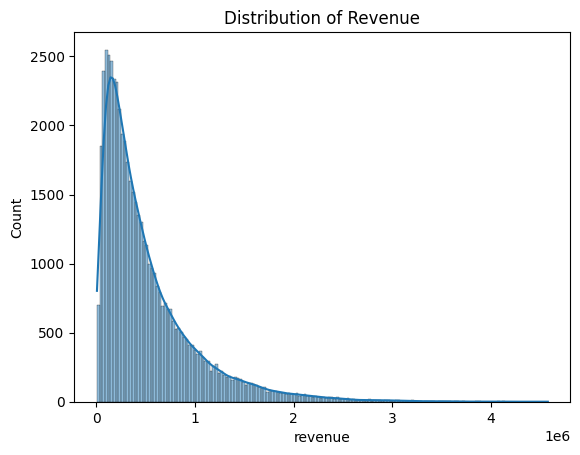

In [ ]:
df_nykaa.shape

(55555, 17)

In [ ]:
df_nykaa.isnull().sum()/df_nykaa.shape[0]*100

,0
campaign_id,0.000000
campaign_type,5.146251
target_audience,4.969850
duration,5.202052
channel_used,5.049050
impressions,5.004050
clicks,5.007650
leads,5.002250
conversions,4.798848
revenue,5.061651


##Concat

In [64]:
df_nykaa.columns = df_nykaa.columns.str.strip().str.lower()

print(df_nykaa.columns)

df_tira.columns = df_tira.columns.str.strip().str.lower()

print(df_tira.columns)

df_purp.columns = df_purp.columns.str.strip().str.lower()

print(df_purp.columns)

Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date', 'brand'],
      dtype='object')
Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date', 'brand'],
      dtype='object')
Index(['campaign_id', 'campaign_type', 'target_audience', 'duration',
       'channel_used', 'impressions', 'clicks', 'leads', 'conversions',
       'revenue', 'acquisition_cost', 'roi', 'language', 'engagement_score',
       'customer_segment', 'date', 'brand'],
      dtype='object')


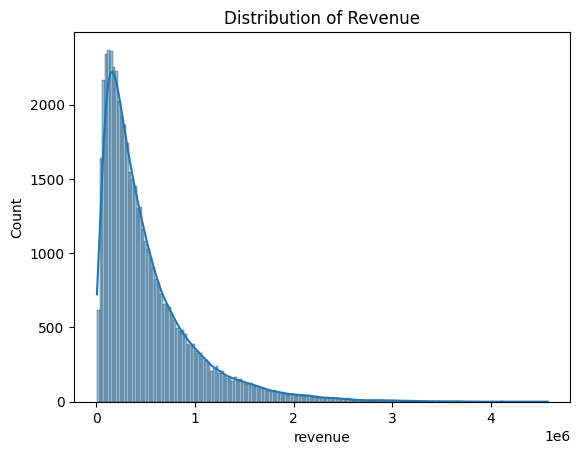

In [65]:
sns.histplot(df_nykaa['revenue'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

In [11]:
print(df_nykaa["revenue"].value_counts().head(10))

revenue
86940.0     6
107100.0    6
199584.0    5
260760.0    5
69930.0     5
734160.0    5
198720.0    5
224400.0    5
415800.0    5
125664.0    5
Name: count, dtype: int64


In [ ]:
df_nykaa.isnull().sum()/df_nykaa.shape[0]*100

,0
campaign_id,0.000000
campaign_type,5.139279
target_audience,4.950825
duration,0.000000
channel_used,5.021495
impressions,0.000000
clicks,0.000000
leads,0.000000
conversions,0.000000
revenue,0.000000


In [ ]:
df_nykaa.describe()

,duration,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score
count,50941.000000,50941.000000,50941.000000,50941.000000,50941.000000,5.094100e+04,50941.000000,50941.000000,50941.00000
mean,17.422469,55253.260674,4673.288491,1864.202548,1006.598457,5.115672e+05,361.615627,2.621984,13.76163
std,7.321968,25106.718636,3080.295585,1396.977979,828.965492,4.804503e+05,514.636848,4.336816,6.15354
min,5.000000,10001.000000,210.000000,56.000000,20.000000,6.183000e+03,9.430000,-0.970000,2.60000
25%,11.000000,34285.000000,2245.000000,819.000000,413.000000,1.813000e+05,110.830000,0.110000,8.68000
50%,17.000000,55226.000000,3906.000000,1477.000000,778.000000,3.608810e+05,207.355000,1.240000,13.60000
75%,24.000000,76296.000000,6525.000000,2550.000000,1345.000000,6.780480e+05,400.870000,3.400000,18.54000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,12423.650000,74.420000,30.91000


In [ ]:
df_purp[num_cols].describe()

,duration,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,engagement_score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.487409,55068.876677,4683.457264,1869.837620,1028.389652,5.136655e+05,378.022692,2.679877,13.759772
std,7.303273,25852.668418,3170.271933,1426.857636,855.926799,4.861114e+05,528.949580,4.432240,6.312747
min,5.000000,0.000000,0.000000,0.000000,0.000000,6.061000e+03,0.000000,-5.222605,0.000000
25%,11.000000,32965.500000,2120.770581,782.000000,401.000000,1.776419e+05,107.380000,0.050000,8.410000
50%,17.484921,55195.000000,3929.000000,1476.000000,776.000000,3.586600e+05,212.700000,1.250000,13.600000
75%,24.000000,77342.500000,6708.000000,2593.000000,1403.000000,6.875885e+05,439.795000,3.575992,18.730000
max,30.000000,117473.084931,15415.128538,8613.000000,6221.000000,4.345920e+06,12109.050000,66.840000,34.527328


In [66]:
print(df_nykaa['conversions'].isna().sum())

0


In [67]:
df_nykaa[df_nykaa['conversions'] > df_nykaa['leads']]

,campaign_id,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,language,engagement_score,customer_segment,date,brand


In [14]:
df_nykaa.isnull().sum()/df_nykaa.shape[0]*100

,0
campaign_id,0.000000
campaign_type,5.139279
target_audience,4.950825
duration,0.000000
channel_used,5.021495
impressions,0.000000
clicks,0.000000
leads,0.000000
conversions,0.000000
revenue,0.000000


In [68]:
#Total Acquisition_cost = conversion*acquisition
df_nykaa['total_acquisition_cost'] = df_nykaa['conversions'] * df_nykaa['acquisition_cost']
df_purp['total_acquisition_cost'] = df_purp['conversions'] * df_purp['acquisition_cost']
df_tira['total_acquisition_cost'] = df_tira['conversions'] * df_tira['acquisition_cost']

In [69]:
#Engagement score correction: Engagement score = (click+leads+conversions)/impression

df_nykaa["engagement_score"] = (df_nykaa["clicks"] +df_nykaa["leads"] +df_nykaa["conversions"])/ (df_nykaa["impressions"]) * 100

df_nykaa["engagement_score"] = df_nykaa["engagement_score"].round(2)


In [70]:
df_tira["engagement_score"] = ((df_tira["clicks"] + df_tira["leads"] + df_tira["conversions"])/ df_tira["impressions"]) * 100

df_tira["engagement_score"] = df_tira["engagement_score"].round(2)


In [71]:
# Purplle
df_purp["engagement_score"] = ((df_purp["clicks"] + df_purp["leads"] + df_purp["conversions"])/ df_purp["impressions"]) * 100

df_purp["engagement_score"] = df_purp["engagement_score"].round(2)

In [72]:
#ROI correction: ROI = revenue-(acquisition*conversion)/(acquisition*conversion)

for df in [df_nykaa, df_tira, df_purp]:
    df["roi"] = ((df["revenue"] - df["total_acquisition_cost"]) / df["total_acquisition_cost"]).round(2)

In [73]:
for df in [df_nykaa, df_tira, df_purp]:
    # replacing infinite values with nan first
    df['roi'] = df['roi'].replace([np.inf, -np.inf], np.nan)

    #then filling the resulting nans with 0
    df['roi'] = df['roi'].fillna(0)



In [74]:
df_nykaa[["roi","engagement_score"]]

,roi,engagement_score
0,2.82,20.98
1,3.26,7.24
2,1.88,25.03
3,0.60,13.15
4,0.80,7.29
...,...,...
50936,-0.32,17.72
50937,12.98,25.26
50938,3.09,27.29
50939,1.85,6.16


In [75]:
df_tira[["roi","engagement_score"]]

,roi,engagement_score
0,0.80,8.59
1,1.46,3.98
2,0.58,8.58
3,3.82,20.76
4,5.92,21.96
...,...,...
51109,1.79,10.66
51110,0.94,11.59
51111,1.64,18.57
51112,1.92,34.93


In [76]:
df_purp[["roi","engagement_score"]]

,roi,engagement_score
0,8.78,19.89
1,0.75,13.12
2,5.56,14.23
3,2.88,13.46
4,0.06,10.13
...,...,...
51112,6.00,22.97
51113,5.53,18.09
51114,1.80,11.37
51115,1.51,13.37


In [24]:
df_nykaa['campaign_id'].duplicated().sum()

np.int64(0)

In [25]:
df_tira['campaign_id'].duplicated().sum()

np.int64(2524)

In [ ]:
df_purp['campaign_id'].duplicated().sum()

np.int64(2683)

In [ ]:
df_tira[df_tira["campaign_id"].duplicated()]["campaign_id"].unique()

array([nan], dtype=object)

In [ ]:
df_tira["campaign_id"].isnull().sum()

np.int64(2525)

In [ ]:
df_purp[df_purp["campaign_id"].duplicated()]["campaign_id"].unique()

array([nan], dtype=object)

In [77]:
#date conversion
df_nykaa['date'] = pd.to_datetime(df_nykaa['date'])
df_tira['date'] = pd.to_datetime(df_tira['date'])
df_purp['date'] = pd.to_datetime(df_purp['date'])

In [78]:
#campaign ID will not be used in training, removing them in all 3 datasets
df_nykaa.drop(columns=["campaign_id"], inplace=True)
df_tira.drop(columns=["campaign_id"], inplace=True)
df_purp.drop(columns=["campaign_id"], inplace=True)

In [28]:
df_nykaa.isnull().sum()/df_nykaa.shape[0]*100

,0
campaign_type,5.139279
target_audience,4.950825
duration,0.000000
channel_used,5.021495
impressions,0.000000
clicks,0.000000
leads,0.000000
conversions,0.000000
revenue,0.000000
acquisition_cost,0.000000


In [ ]:
df_tira.isnull().sum()/df_tira.shape[0]*100

,0
campaign_type,4.876249
target_audience,4.795248
duration,0.000000
channel_used,4.919449
impressions,0.000000
clicks,0.000000
leads,0.000000
conversions,0.000000
revenue,0.000000
acquisition_cost,0.000000


In [ ]:
df_purp.isnull().sum()/df_purp.shape[0]*100

,0
campaign_type,5.022050
target_audience,4.944649
duration,0.000000
channel_used,4.939249
impressions,0.000000
clicks,0.000000
leads,0.000000
conversions,0.000000
revenue,0.000000
acquisition_cost,0.000000


In [79]:
#filling NA in cat columns using mode.
df = [df_nykaa, df_tira, df_purp]

cat_cols = [
    "campaign_type",
    "target_audience",
    "channel_used",
    "language",
    "customer_segment"
]

for df in df:
       for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
        df['date'] = df['date'].ffill().bfill()


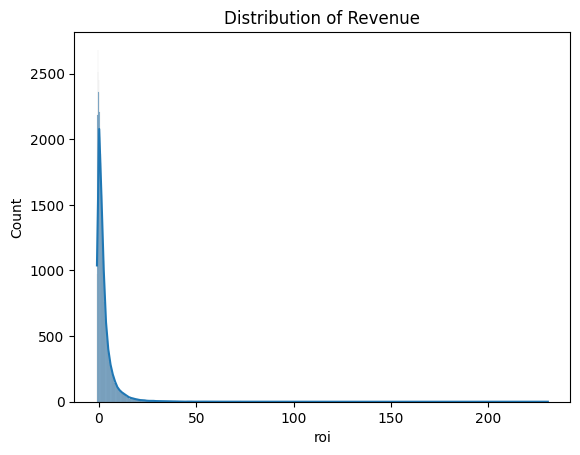

In [80]:
sns.histplot(df_nykaa['roi'], kde=True)
plt.title('Distribution of Revenue')
plt.show()

In [81]:
df_nykaa[df_nykaa['conversions'] > df_nykaa['leads']]

,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,language,engagement_score,customer_segment,date,brand,total_acquisition_cost


In [32]:
df_purp['roi'].describe()

,roi
count,51117.000000
mean,2.807390
std,5.695707
min,-0.970000
25%,0.080000
50%,1.250000
75%,3.420000
max,210.960000


In [ ]:
df_tira.isnull().sum()

,0
campaign_type,0
target_audience,0
duration,0
channel_used,0
impressions,0
clicks,0
leads,0
conversions,0
revenue,0
acquisition_cost,0


In [ ]:
df_purp.isnull().sum()

,0
campaign_type,0
target_audience,0
duration,0
channel_used,0
impressions,0
clicks,0
leads,0
conversions,0
revenue,0
acquisition_cost,0


In [82]:
df_final = pd.concat( [ df_nykaa, df_tira, df_purp ], ignore_index=True )

In [83]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153172 entries, 0 to 153171
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   campaign_type           153172 non-null  object        
 1   target_audience         153172 non-null  object        
 2   duration                153172 non-null  float64       
 3   channel_used            153172 non-null  object        
 4   impressions             153172 non-null  float64       
 5   clicks                  153172 non-null  float64       
 6   leads                   153172 non-null  float64       
 7   conversions             153172 non-null  float64       
 8   revenue                 153172 non-null  float64       
 9   acquisition_cost        153172 non-null  float64       
 10  roi                     153172 non-null  float64       
 11  language                153172 non-null  object        
 12  engagement_score        153172

In [84]:
df_final.shape

(153172, 17)

In [36]:
df_final.isnull().sum()

,0
campaign_type,0
target_audience,0
duration,0
channel_used,0
impressions,0
clicks,0
leads,0
conversions,0
revenue,0
acquisition_cost,0


In [37]:
df_final[['acquisition_cost', 'impressions', 'clicks', 'leads', 'conversions', 'revenue']].describe()

,acquisition_cost,impressions,clicks,leads,conversions,revenue
count,153172.000000,153172.000000,153172.000000,153172.000000,153172.000000,1.531720e+05
mean,362.466189,55196.217334,4671.827201,1860.232405,1002.803260,5.101125e+05
std,513.541843,25177.281921,3086.773698,1394.031665,825.409381,4.789832e+05
min,9.340000,10001.000000,207.000000,48.000000,17.000000,3.895000e+03
25%,112.140000,34102.000000,2233.000000,816.000000,413.000000,1.811902e+05
50%,209.060000,55182.500000,3906.000000,1476.000000,775.000000,3.600405e+05
75%,403.720000,76376.250000,6523.000000,2547.000000,1334.000000,6.776555e+05
max,15038.000000,100000.000000,14888.000000,8876.000000,6686.000000,4.579910e+06


In [85]:
df_final.columns.tolist()

['campaign_type',
 'target_audience',
 'duration',
 'channel_used',
 'impressions',
 'clicks',
 'leads',
 'conversions',
 'revenue',
 'acquisition_cost',
 'roi',
 'language',
 'engagement_score',
 'customer_segment',
 'date',
 'brand',
 'total_acquisition_cost']

In [86]:
type(df_final)

pandas.core.frame.DataFrame

In [87]:
df_final.head()

,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,language,engagement_score,customer_segment,date,brand,total_acquisition_cost
0,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,207.355,2.82,Hindi,20.98,College Students,2025-04-29,nykaa,488321.025
1,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,3.26,Hindi,7.24,College Students,2025-04-06,nykaa,245386.310
2,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.600,1.88,English,25.03,College Students,2025-01-14,nykaa,68403.000
3,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.070,0.60,Hindi,13.15,College Students,2025-06-04,nykaa,235869.290
4,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.600,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29,nykaa,287578.800


In [106]:
df_final.to_csv(
    "marketing_clean_merge.csv",
    index=False
)

In [107]:
df_final.brand.value_counts()

,count
brand,
purplle,44865
tira,44851
nykaa,44738
